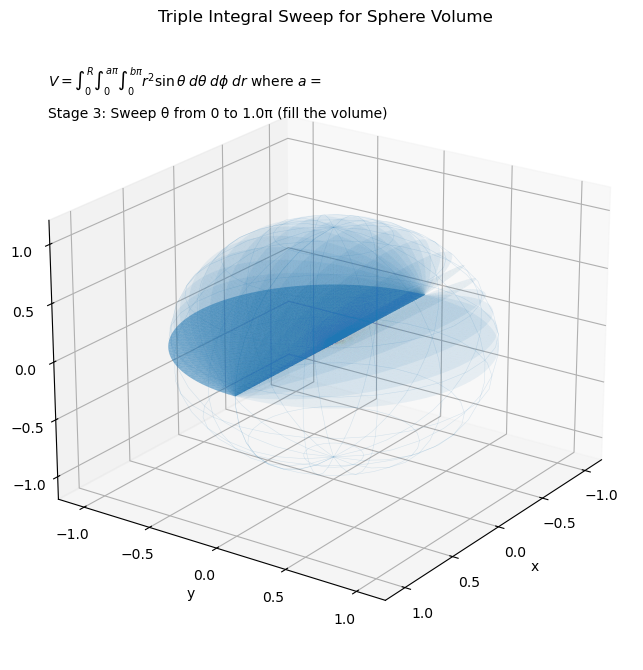

Saved: sphere_triple_integral_filling.gif


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# ---------------------------
# Parameters
# ---------------------------
R = 1.0
a = 1.0
b = 1.0

N1 = 70     # expand r
N2 = 60    # sweep phi
N3 = 160    # flip theta and fill volume
interval_ms = 30

phival = 1

# Disk mesh resolution (bigger = smoother, slower)
disk_nr = 22
disk_nphi = 70

# Number of "slices" used to fill volume during Stage 3
# (bigger = more filled look, slower)
fill_slices = 20

# Output file
OUT_GIF = "sphere_triple_integral_filling.gif"

# ---------------------------
# Geometry helpers
# ---------------------------
def rotate_x(points, theta):
    """Rotate Nx3 points about x-axis by theta."""
    ct, st = np.cos(theta), np.sin(theta)
    x = points[:, 0]
    y = ct * points[:, 1] - st * points[:, 2]
    z = st * points[:, 1] + ct * points[:, 2]
    return np.column_stack([x, y, z])

def disk_triangles(radius, phi_max, theta):
    """
    Filled disk (triangulated) in local xy-plane, then rotated about x by theta.
    phi_max controls partial sweep 0..phi_max.
    """
    phis = np.linspace(0, phi_max, disk_nphi)
    rs = np.linspace(0, radius, disk_nr)

    tris = []

    for i in range(len(rs) - 1):
        r0, r1 = rs[i], rs[i + 1]
        for j in range(len(phis) - 1):
            p0, p1 = phis[j], phis[j + 1]

            # Quad corners in local xy-plane (z=0)
            v00 = np.array([r0*np.cos(p0), r0*np.sin(p0), 0.0])
            v01 = np.array([r0*np.cos(p1), r0*np.sin(p1), 0.0])
            v10 = np.array([r1*np.cos(p0), r1*np.sin(p0), 0.0])
            v11 = np.array([r1*np.cos(p1), r1*np.sin(p1), 0.0])

            # Rotate about x-axis
            V = np.vstack([v00, v01, v10, v11])
            V = rotate_x(V, theta)
            v00r, v01r, v10r, v11r = V

            # Two triangles
            tris.append([tuple(v00r), tuple(v10r), tuple(v11r)])
            tris.append([tuple(v00r), tuple(v11r), tuple(v01r)])

    return tris

def filled_volume_tris(radius, theta_max):
    """
    Approximate filled volume by stacking full disks from theta=0..theta_max.
    Each disk is a triangulated surface; stacking gives a "filled" look.
    """
    if theta_max <= 0:
        return []

    thetas = np.linspace(0, theta_max, max(2, fill_slices))
    all_tris = []
    for th in thetas:
        all_tris.extend(disk_triangles(radius, phi_max=a*np.pi, theta=th))
    return all_tris

# ---------------------------
# Figure setup
# ---------------------------
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")
ax.view_init(elev=22, azim=35)

lim = 1.2 * R
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_zlim(-lim, lim)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

ax.set_title("Triple Integral Sweep for Sphere Volume", pad=16)
ax.text2D(
    0.05, 0.93,
    r"$V=\int_{0}^{R}\int_{0}^{a\pi}\int_{0}^{b\pi} r^2\sin\theta\; d\theta\; d\phi\; dr$ where $a=$",
    transform=ax.transAxes
)
stage_text = ax.text2D(0.05, 0.88, "", transform=ax.transAxes)

# Faint wireframe sphere for context
u = np.linspace(0, 2*np.pi, 30)
v = np.linspace(0, np.pi, 18)
xs = R * np.outer(np.cos(u), np.sin(v))
ys = R * np.outer(np.sin(u), np.sin(v))
zs = R * np.outer(np.ones_like(u), np.cos(v))
ax.plot_wireframe(xs, ys, zs, rstride=2, cstride=2, linewidth=0.4, alpha=0.15)

# Animated objects
line_plot, = ax.plot([0, 0], [0, 0], [0, 0], lw=3)  # used only in Stage 1
disk_poly = Poly3DCollection([], alpha=0.35)
ax.add_collection3d(disk_poly)

volume_poly = Poly3DCollection([], alpha=0.12)  # stacked disks for "filled volume"
ax.add_collection3d(volume_poly)

# ---------------------------
# Animation logic
# ---------------------------
total_frames = N1 + N2 + N3

def hide_line():
    # Setting NaNs is the cleanest way to make the 3D line vanish.
    line_plot.set_data([np.nan, np.nan], [np.nan, np.nan])
    line_plot.set_3d_properties([np.nan, np.nan])

def update(frame):
    # Clear surfaces each frame; we'll redraw what we need
    disk_poly.set_verts([])
    volume_poly.set_verts([])

    # Default alphas (tuned so you can see "filling")
    disk_poly.set_alpha(0.35)
    volume_poly.set_alpha(0.12)

    if frame < N1:
        # Stage 1: expand radius r from 0 to R along +x
        t = frame / (N1 - 1)
        r = t * R
        stage_text.set_text("Stage 1: Expand radius r from 0 to R")

        line_plot.set_data([0, r], [0, 0])
        line_plot.set_3d_properties([0, 0])

    elif frame < N1 + N2:
        # Stage 2: sweep phi to make disk in xy-plane (theta = pi/2)
        hide_line()

        k = frame - N1
        t = k / (N2 - 1)
        phi = t * a * np.pi
        stage_text.set_text(f"Stage 2: Sweep φ from 0 to {a}π (disk in xy-plane)")

        tris = disk_triangles(R, phi_max=phi, theta=0.0)
        disk_poly.set_verts(tris)

    else:
        # Stage 3: flip theta 0..pi AND fill volume up to current theta
        hide_line()

        k = frame - (N1 + N2)
        t = k / (N3 - 1)
        theta = t * b * np.pi
        stage_text.set_text(f"Stage 3: Sweep θ from 0 to {b}π (fill the volume)")

        # Optional: still show the "current" disk boundary (subtle)
        disk_poly.set_verts(disk_triangles(R, phi_max= a *np.pi, theta=theta))
        disk_poly.set_alpha(0.5)

        # This is the "filled volume" effect: stack disks from 0..theta
        vtris = filled_volume_tris(R, theta_max=theta)
        volume_poly.set_verts(vtris)

        # Make it slightly denser near the middle for a nicer visual
        volume_poly.set_alpha(0.08 + 0.10 * np.sin(theta))

    return line_plot, disk_poly, volume_poly, stage_text

ani = FuncAnimation(fig, update, frames=total_frames, interval=interval_ms, blit=False)

# Save GIF
ani.save(OUT_GIF, writer=PillowWriter(fps=30))

plt.show()
print(f"Saved: {OUT_GIF}")

Initial energy: 9.926384040481636
Final energy:   9.926300545265775
Max |ΔE|:       8.434010877778064e-05


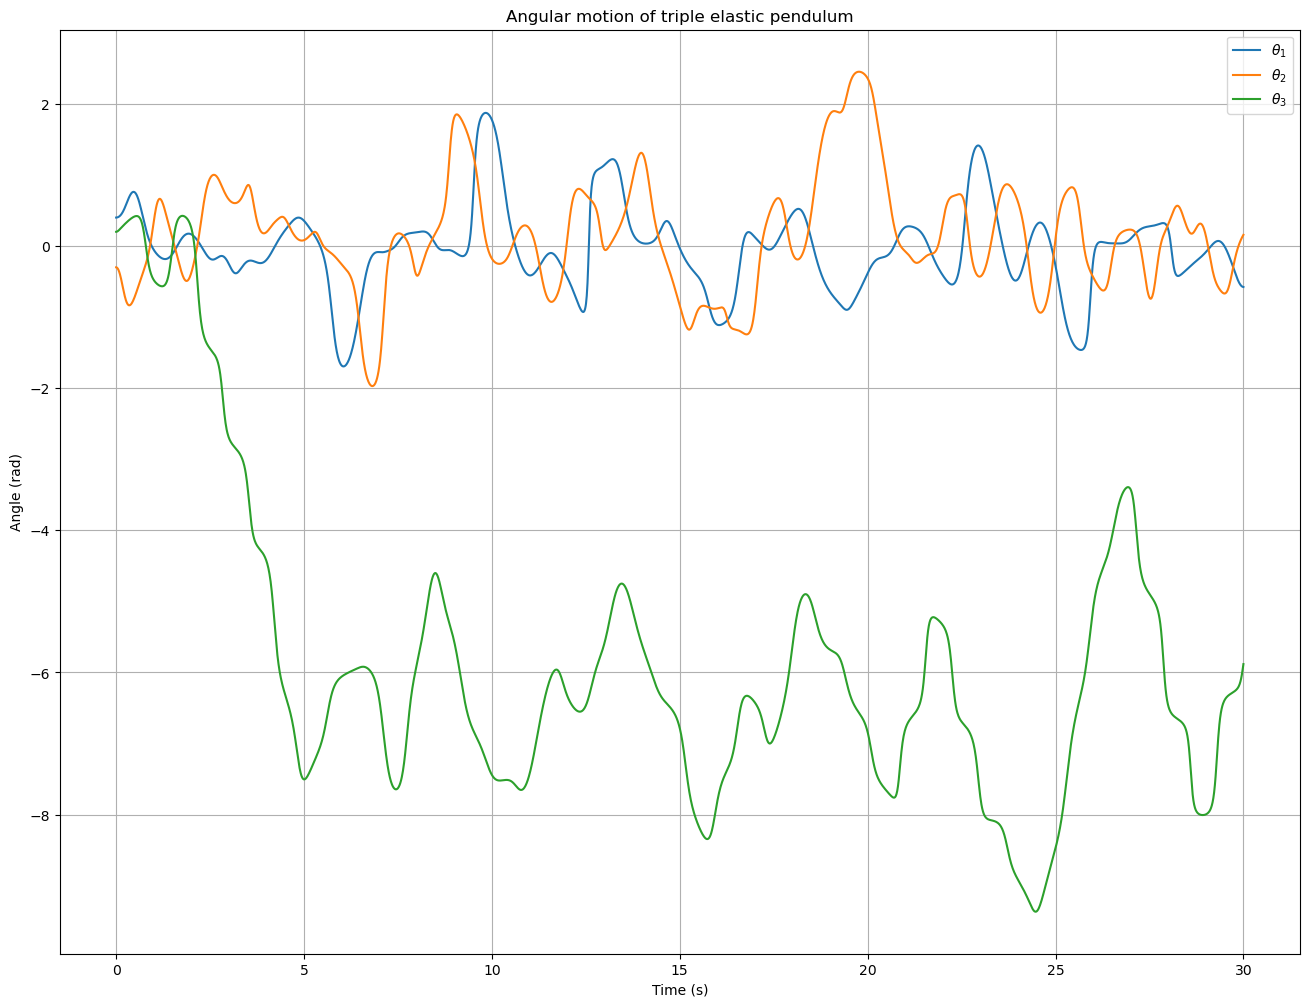

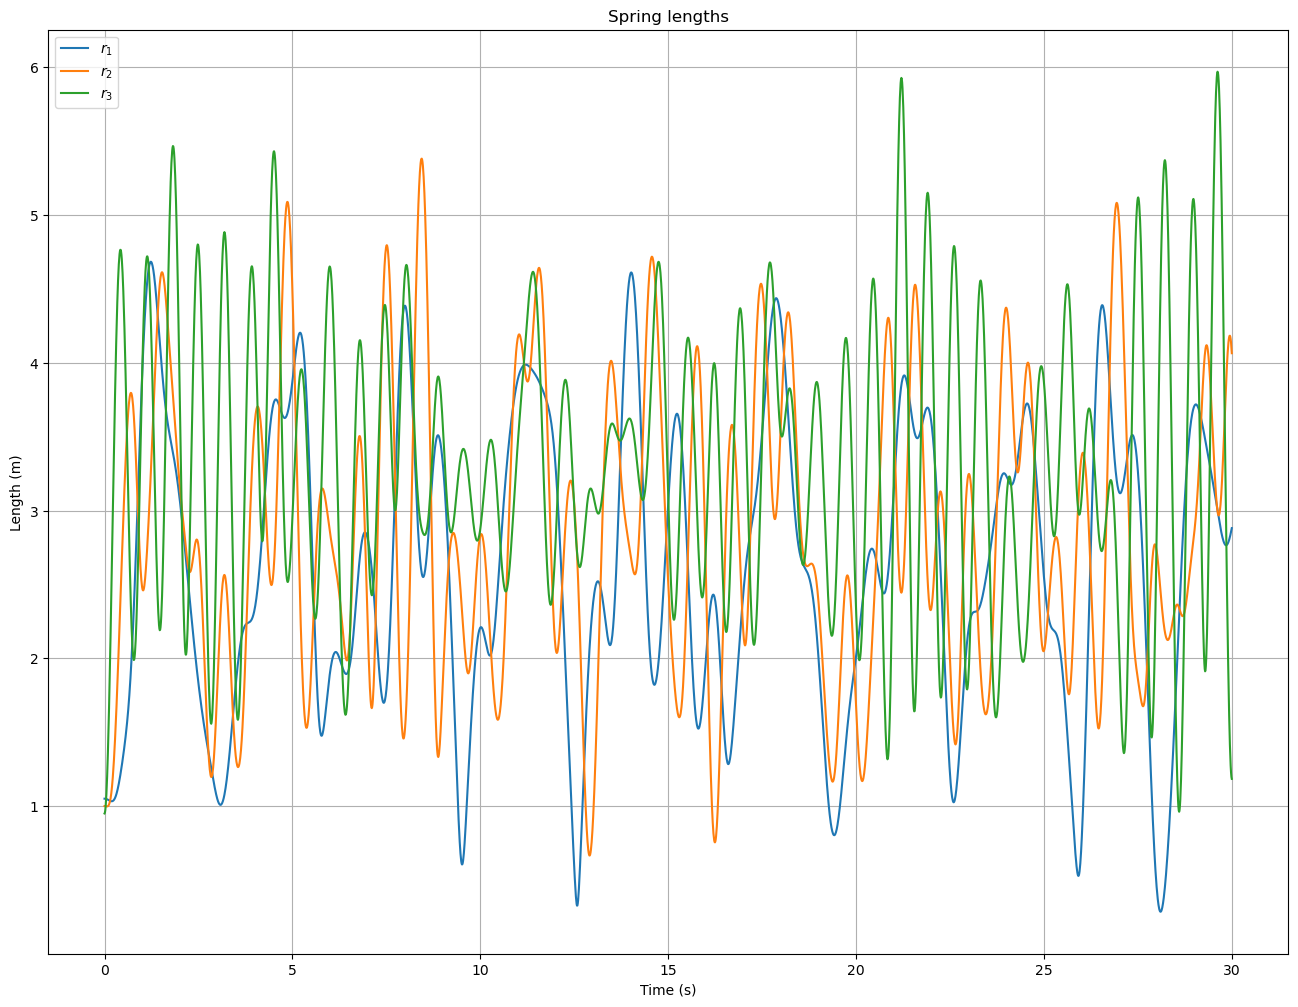

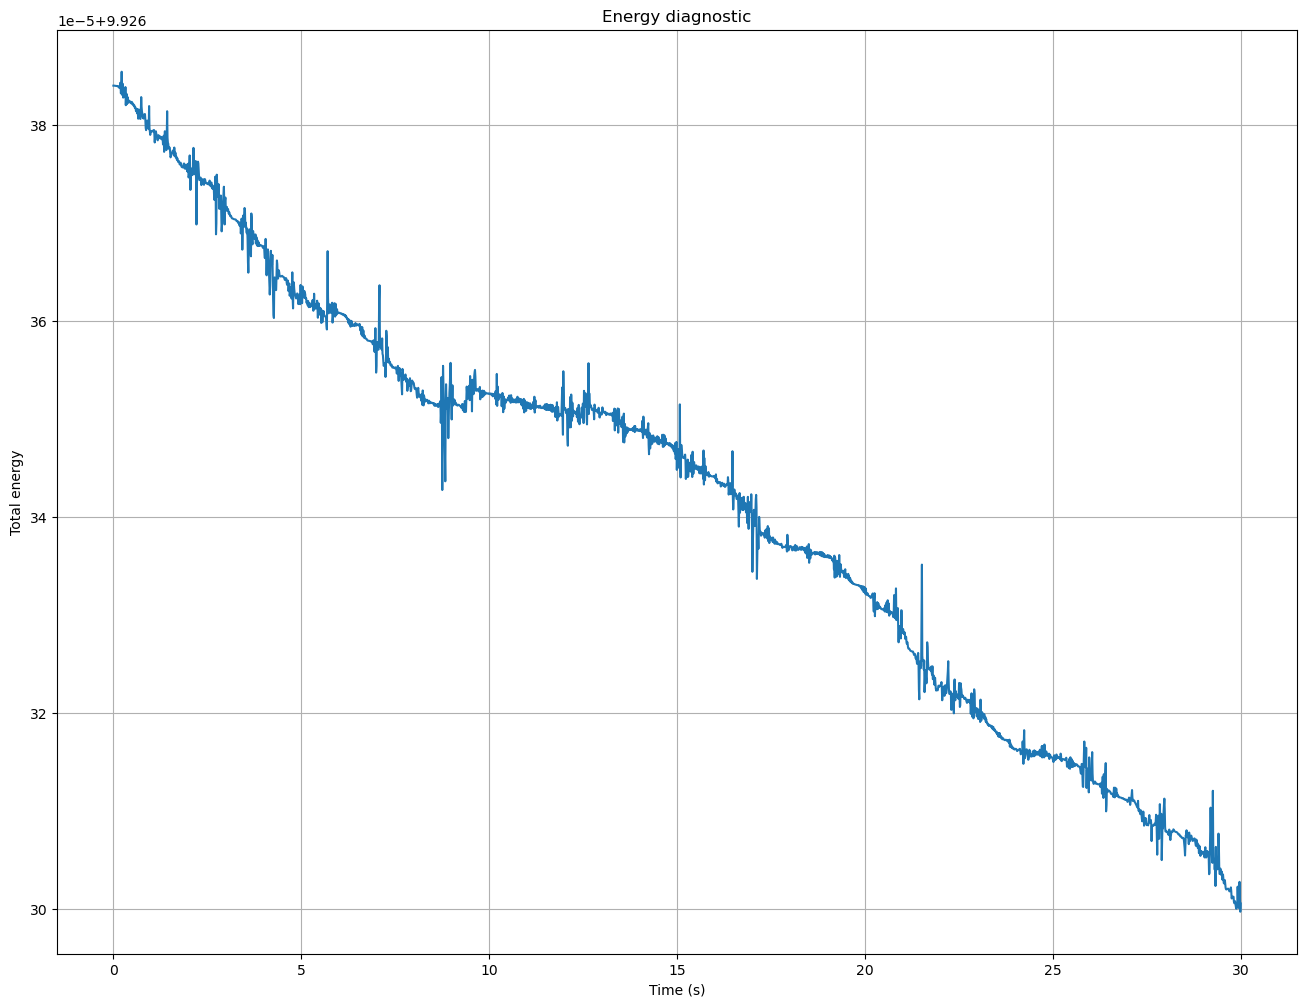

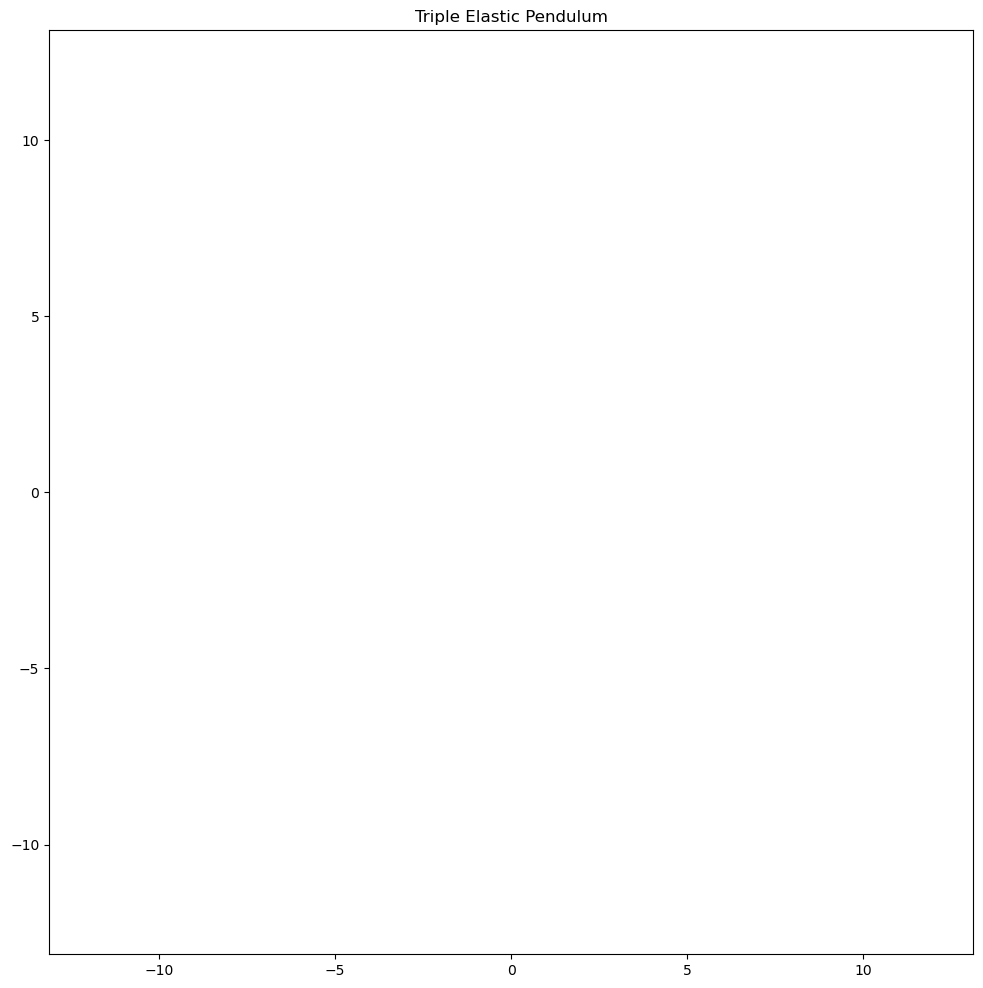

In [8]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from matplotlib.animation import FuncAnimation

# ============================================================
# 1. Symbolic setup
# ============================================================

t = sp.symbols('t', real=True)

# Generalized coordinates as functions of time
r1 = sp.Function('r1')(t)
th1 = sp.Function('th1')(t)
r2 = sp.Function('r2')(t)
th2 = sp.Function('th2')(t)
r3 = sp.Function('r3')(t)
th3 = sp.Function('th3')(t)

q = [r1, th1, r2, th2, r3, th3]
qd = [sp.diff(var, t) for var in q]
qdd = [sp.diff(var, t, 2) for var in q]

# Parameters
m1, m2, m3 = sp.symbols('m1 m2 m3', positive=True, real=True)
k1, k2, k3 = sp.symbols('k1 k2 k3', positive=True, real=True)
L1, L2, L3 = sp.symbols('L1 L2 L3', positive=True, real=True)
g = sp.symbols('g', positive=True, real=True)

# ============================================================
# 2. Position vectors
# ============================================================

x1 = r1 * sp.sin(th1)
y1 = -r1 * sp.cos(th1)

x2 = x1 + r2 * sp.sin(th2)
y2 = y1 - r2 * sp.cos(th2)

x3 = x2 + r3 * sp.sin(th3)
y3 = y2 - r3 * sp.cos(th3)

# Velocities
vx1 = sp.diff(x1, t)
vy1 = sp.diff(y1, t)

vx2 = sp.diff(x2, t)
vy2 = sp.diff(y2, t)

vx3 = sp.diff(x3, t)
vy3 = sp.diff(y3, t)

v1_sq = sp.simplify(vx1**2 + vy1**2)
v2_sq = sp.simplify(vx2**2 + vy2**2)
v3_sq = sp.simplify(vx3**2 + vy3**2)

# ============================================================
# 3. Energies and Lagrangian
# ============================================================

T = sp.simplify(
    sp.Rational(1, 2) * m1 * v1_sq +
    sp.Rational(1, 2) * m2 * v2_sq +
    sp.Rational(1, 2) * m3 * v3_sq
)

V_spring = sp.simplify(
    sp.Rational(1, 2) * k1 * (r1 - L1)**2 +
    sp.Rational(1, 2) * k2 * (r2 - L2)**2 +
    sp.Rational(1, 2) * k3 * (r3 - L3)**2
)

V_grav = sp.simplify(m1 * g * y1 + m2 * g * y2 + m3 * g * y3)

V = sp.simplify(V_spring + V_grav)
Lag = sp.simplify(T - V)

# ============================================================
# 4. Euler-Lagrange equations
# ============================================================

EL_eqs = []
for qi, qdi in zip(q, qd):
    eq = sp.simplify(sp.diff(sp.diff(Lag, qdi), t) - sp.diff(Lag, qi))
    EL_eqs.append(eq)

# Solve for second derivatives
sol = sp.solve(EL_eqs, qdd, simplify=False, rational=False, dict=True)

if not sol:
    raise RuntimeError("SymPy could not solve for accelerations.")

sol = sol[0]

# ============================================================
# 5. Convert symbolic expressions to numerical functions
# ============================================================

# Replace q(t), qdot(t) with plain symbols for lambdify
r1_s, th1_s, r2_s, th2_s, r3_s, th3_s = sp.symbols('r1_s th1_s r2_s th2_s r3_s th3_s')
dr1_s, dth1_s, dr2_s, dth2_s, dr3_s, dth3_s = sp.symbols('dr1_s dth1_s dr2_s dth2_s dr3_s dth3_s')

subs_dict = {
    r1: r1_s, th1: th1_s, r2: r2_s, th2: th2_s, r3: r3_s, th3: th3_s,
    sp.diff(r1, t): dr1_s, sp.diff(th1, t): dth1_s,
    sp.diff(r2, t): dr2_s, sp.diff(th2, t): dth2_s,
    sp.diff(r3, t): dr3_s, sp.diff(th3, t): dth3_s
}

ddr1_expr = sp.simplify(sol[sp.diff(r1, t, 2)].subs(subs_dict))
ddth1_expr = sp.simplify(sol[sp.diff(th1, t, 2)].subs(subs_dict))
ddr2_expr = sp.simplify(sol[sp.diff(r2, t, 2)].subs(subs_dict))
ddth2_expr = sp.simplify(sol[sp.diff(th2, t, 2)].subs(subs_dict))
ddr3_expr = sp.simplify(sol[sp.diff(r3, t, 2)].subs(subs_dict))
ddth3_expr = sp.simplify(sol[sp.diff(th3, t, 2)].subs(subs_dict))

vars_for_lambdify = (
    r1_s, th1_s, r2_s, th2_s, r3_s, th3_s,
    dr1_s, dth1_s, dr2_s, dth2_s, dr3_s, dth3_s,
    m1, m2, m3, k1, k2, k3, L1, L2, L3, g
)

f_ddr1 = sp.lambdify(vars_for_lambdify, ddr1_expr, modules='numpy')
f_ddth1 = sp.lambdify(vars_for_lambdify, ddth1_expr, modules='numpy')
f_ddr2 = sp.lambdify(vars_for_lambdify, ddr2_expr, modules='numpy')
f_ddth2 = sp.lambdify(vars_for_lambdify, ddth2_expr, modules='numpy')
f_ddr3 = sp.lambdify(vars_for_lambdify, ddr3_expr, modules='numpy')
f_ddth3 = sp.lambdify(vars_for_lambdify, ddth3_expr, modules='numpy')

# Total energy for diagnostics
T_num = sp.lambdify(vars_for_lambdify, T.subs(subs_dict), modules='numpy')
V_num = sp.lambdify(vars_for_lambdify, V.subs(subs_dict), modules='numpy')

# ============================================================
# 6. Numerical parameters
# ============================================================

params = {
    "m1": 3.0,
    "m2": 2.0,
    "m3": 1.0,
    "k1": 40.0,
    "k2": 40.0,
    "k3": 40.0,
    "L1": 1.0,
    "L2": 2.0,
    "L3": 3.0,
    "g": 9.81
}

p_tuple = (
    params["m1"], params["m2"], params["m3"],
    params["k1"], params["k2"], params["k3"],
    params["L1"], params["L2"], params["L3"],
    params["g"]
)

# Initial conditions:
# [r1, th1, r2, th2, r3, th3, dr1, dth1, dr2, dth2, dr3, dth3]
y0 = np.array([
    1.05, 0.4,
    1.00, -0.3,
    0.95, 0.2,
    0.0, 0.0,
    0.0, 0.0,
    0.0, 0.0
], dtype=float)

t_span = (0.0, 30.0)
t_eval = np.linspace(t_span[0], t_span[1], 3000)

# ============================================================
# 7. ODE system
# ============================================================

def rhs(t_num, y):
    r1v, th1v, r2v, th2v, r3v, th3v, dr1v, dth1v, dr2v, dth2v, dr3v, dth3v = y

    args = (
        r1v, th1v, r2v, th2v, r3v, th3v,
        dr1v, dth1v, dr2v, dth2v, dr3v, dth3v,
        *p_tuple
    )

    ddr1v = f_ddr1(*args)
    ddth1v = f_ddth1(*args)
    ddr2v = f_ddr2(*args)
    ddth2v = f_ddth2(*args)
    ddr3v = f_ddr3(*args)
    ddth3v = f_ddth3(*args)

    return np.array([
        dr1v, dth1v,
        dr2v, dth2v,
        dr3v, dth3v,
        ddr1v, ddth1v,
        ddr2v, ddth2v,
        ddr3v, ddth3v
    ], dtype=float)

# ============================================================
# 8. Solve
# ============================================================

sol_ivp = solve_ivp(
    rhs,
    t_span,
    y0,
    t_eval=t_eval,
    rtol=1e-8,
    atol=1e-8,
    method='RK45'
)

if not sol_ivp.success:
    raise RuntimeError("ODE solver failed: " + sol_ivp.message)

Y = sol_ivp.y
time = sol_ivp.t

r1_arr, th1_arr = Y[0], Y[1]
r2_arr, th2_arr = Y[2], Y[3]
r3_arr, th3_arr = Y[4], Y[5]
dr1_arr, dth1_arr = Y[6], Y[7]
dr2_arr, dth2_arr = Y[8], Y[9]
dr3_arr, dth3_arr = Y[10], Y[11]

# ============================================================
# 9. Cartesian coordinates
# ============================================================

x1_arr = r1_arr * np.sin(th1_arr)
y1_arr = -r1_arr * np.cos(th1_arr)

x2_arr = x1_arr + r2_arr * np.sin(th2_arr)
y2_arr = y1_arr - r2_arr * np.cos(th2_arr)

x3_arr = x2_arr + r3_arr * np.sin(th3_arr)
y3_arr = y2_arr - r3_arr * np.cos(th3_arr)

# ============================================================
# 10. Energy diagnostic
# ============================================================

E_arr = np.empty_like(time)
for i in range(len(time)):
    args = (
        r1_arr[i], th1_arr[i], r2_arr[i], th2_arr[i], r3_arr[i], th3_arr[i],
        dr1_arr[i], dth1_arr[i], dr2_arr[i], dth2_arr[i], dr3_arr[i], dth3_arr[i],
        *p_tuple
    )
    E_arr[i] = T_num(*args) + V_num(*args)

print("Initial energy:", E_arr[0])
print("Final energy:  ", E_arr[-1])
print("Max |ΔE|:      ", np.max(np.abs(E_arr - E_arr[0])))

# ============================================================
# 11. Static plots
# ============================================================

fig1, ax1 = plt.subplots(figsize=(16, 12))
ax1.plot(time, th1_arr, label=r'$\theta_1$')
ax1.plot(time, th2_arr, label=r'$\theta_2$')
ax1.plot(time, th3_arr, label=r'$\theta_3$')
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Angle (rad)")
ax1.set_title("Angular motion of triple elastic pendulum")
ax1.legend()
ax1.grid(True)

fig2, ax2 = plt.subplots(figsize=(16, 12))
ax2.plot(time, r1_arr, label=r'$r_1$')
ax2.plot(time, r2_arr, label=r'$r_2$')
ax2.plot(time, r3_arr, label=r'$r_3$')
ax2.set_xlabel("Time (s)")
ax2.set_ylabel("Length (m)")
ax2.set_title("Spring lengths")
ax2.legend()
ax2.grid(True)

fig3, ax3 = plt.subplots(figsize=(16, 12))
ax3.plot(time, E_arr)
ax3.set_xlabel("Time (s)")
ax3.set_ylabel("Total energy")
ax3.set_title("Energy diagnostic")
ax3.grid(True)

# ============================================================
# 12. Animation
# ============================================================

fig_anim, ax_anim = plt.subplots(figsize=(16, 12))
ax_anim.set_aspect('equal')

# Calculate actual max extent from simulation data
x_max = max(np.max(np.abs(x1_arr)), np.max(np.abs(x2_arr)), np.max(np.abs(x3_arr)))
y_max = max(np.max(np.abs(y1_arr)), np.max(np.abs(y2_arr)), np.max(np.abs(y3_arr)))
max_len = max(x_max, y_max) * 1.1  # Add 10% margin

ax_anim.set_xlim(-max_len, max_len)
ax_anim.set_ylim(-max_len, max_len)
ax_anim.set_title("Triple Elastic Pendulum")

line, = ax_anim.plot([], [], 'o-', lw=2)
trail, = ax_anim.plot([], [], '-', lw=1)
time_text = ax_anim.text(0.02, 0.95, "", transform=ax_anim.transAxes)

trail_length = 200

def init():
    line.set_data([], [])
    trail.set_data([], [])
    time_text.set_text("")
    return line, trail, time_text

def update(frame):
    xs = [0, x1_arr[frame], x2_arr[frame], x3_arr[frame]]
    ys = [0, y1_arr[frame], y2_arr[frame], y3_arr[frame]]
    line.set_data(xs, ys)

    start = max(0, frame - trail_length)
    trail.set_data(x3_arr[start:frame+1], y3_arr[start:frame+1])

    time_text.set_text(f"t = {time[frame]:.2f} s")
    return line, trail, time_text

ani = FuncAnimation(
    fig_anim,
    update,
    frames=len(time),
    init_func=init,
    interval=20,
    blit=True
)

plt.show()

# To save animation, uncomment one of these:
ani.save("triple_elastic_pendulum.gif", writer="pillow", fps=30)
# ani.save("triple_elastic_pendulum.mp4", writer="ffmpeg", fps=30)


In [9]:
import numpy as np

def conservation_report(time, masses, x_series, y_series, energy_series):
    """
    Compute momentum and energy conservation diagnostics.

    Parameters
    ----------
    time : (N,) array
        Time samples.
    masses : sequence of length M
        Masses for each body.
    x_series, y_series : sequence of M arrays, each shape (N,)
        Cartesian positions for each mass.
    energy_series : (N,) array
        Total energy over time.

    Returns
    -------
    results : dict
        Contains momentum components/magnitude, energy, and drift metrics.
    """
    time = np.asarray(time, dtype=float)
    masses = np.asarray(masses, dtype=float)
    x_series = [np.asarray(x, dtype=float) for x in x_series]
    y_series = [np.asarray(y, dtype=float) for y in y_series]
    E = np.asarray(energy_series, dtype=float)

    if len(masses) != len(x_series) or len(masses) != len(y_series):
        raise ValueError("masses, x_series, and y_series must have the same length.")

    # Numerical velocities from position histories
    vx_series = [np.gradient(x, time) for x in x_series]
    vy_series = [np.gradient(y, time) for y in y_series]

    # Total linear momentum
    px = np.zeros_like(time)
    py = np.zeros_like(time)
    for m, vx, vy in zip(masses, vx_series, vy_series):
        px += m * vx
        py += m * vy

    p_mag = np.sqrt(px**2 + py**2)

    # Drift diagnostics
    def drift_stats(arr):
        arr0 = arr[0]
        drift = arr - arr0
        max_abs = np.max(np.abs(drift))
        rel = max_abs / (np.abs(arr0) + 1e-12)
        return arr0, arr[-1], max_abs, rel

    px0, pxf, px_max, px_rel = drift_stats(px)
    py0, pyf, py_max, py_rel = drift_stats(py)
    p00, p0f, p0_max, p0_rel = drift_stats(p_mag)
    E0, Ef, E_max, E_rel = drift_stats(E)

    print("=== Conservation diagnostics ===")
    print(f"Energy: E0={E0:.6e}, Ef={Ef:.6e}, max|ΔE|={E_max:.6e}, rel={E_rel:.3e}")
    print(f"Px:     P0={px0:.6e}, Pf={pxf:.6e}, max|ΔP|={px_max:.6e}, rel={px_rel:.3e}")
    print(f"Py:     P0={py0:.6e}, Pf={pyf:.6e}, max|ΔP|={py_max:.6e}, rel={py_rel:.3e}")
    print(f"|P|:    P0={p00:.6e}, Pf={p0f:.6e}, max|Δ|P||={p0_max:.6e}, rel={p0_rel:.3e}")

    return {
        "time": time,
        "px": px,
        "py": py,
        "p_mag": p_mag,
        "energy": E,
        "energy_metrics": {"initial": E0, "final": Ef, "max_abs_drift": E_max, "max_rel_drift": E_rel},
        "px_metrics": {"initial": px0, "final": pxf, "max_abs_drift": px_max, "max_rel_drift": px_rel},
        "py_metrics": {"initial": py0, "final": pyf, "max_abs_drift": py_max, "max_rel_drift": py_rel},
        "p_mag_metrics": {"initial": p00, "final": p0f, "max_abs_drift": p0_max, "max_rel_drift": p0_rel},
    }

# Example use with arrays from the triple-pendulum cell above:
cons = conservation_report(
    time=time,
    masses=[params["m1"], params["m2"], params["m3"]],
    x_series=[x1_arr, x2_arr, x3_arr],
    y_series=[y1_arr, y2_arr, y3_arr],
    energy_series=E_arr,
)

=== Conservation diagnostics ===
Energy: E0=9.926384e+00, Ef=9.926301e+00, max|ΔE|=8.434011e-05, rel=8.497e-06
Px:     P0=-3.894641e-03, Pf=7.427756e+00, max|ΔP|=2.576634e+01, rel=6.616e+03
Py:     P0=-2.851874e-01, Pf=1.086713e+01, max|ΔP|=3.695157e+01, rel=1.296e+02
|P|:    P0=2.852140e-01, Pf=1.316306e+01, max|Δ|P||=4.147189e+01, rel=1.454e+02


In [5]:
import numpy as np

# --- INPUT VALUES ---
t = 1.15e-3        # thickness (m)
dt = 0.01e-3       # uncertainty in thickness (m)

N = 18.8             # fringe count
dN = 0.66           # uncertainty in fringe count

theta = np.deg2rad(10)   # angle in radians
dtheta = np.deg2rad(0.1) # uncertainty in angle

lam = 633e-9       # wavelength (m)
dlam = 1e-9        # uncertainty in wavelength (m)

# --- COMMON TERMS ---
A = (2*t - N*lam)
B = (1 - np.cos(theta))
C = (2*t*B - N*lam)

# --- REFRACTIVE INDEX ---
n = (A * B) / C

# --- PARTIAL DERIVATIVES ---

# dn/dt
dn_dt = (
    (2*B * C - A * B * 2*B) / (C**2)
)

# dn/dN
dn_dN = (
    ((-lam)*B * C - A * B * (-lam)) / (C**2)
)

# dn/dtheta
dn_dtheta = (
    (A * np.sin(theta) * C - A * B * (2*t*np.sin(theta))) / (C**2)
)

# dn/dlambda
dn_dlam = (
    ((-N)*B * C - A * B * (-N)) / (C**2)
)

# --- UNCERTAINTY PROPAGATION ---
dn = np.sqrt(
    (dn_dt * dt)**2 +
    (dn_dN * dN)**2 +
    (dn_dtheta * dtheta)**2 +
    (dn_dlam * dlam)**2
)

# --- OUTPUT ---
print(f"Refractive index: n = {n:.4f}")
print(f"Uncertainty: Δn = {dn:.4f}")
print(f"Final result: n = {n:.4f} ± {dn:.4f}")


Refractive index: n = 1.5086
Uncertainty: Δn = 0.0320
Final result: n = 1.5086 ± 0.0320


In [6]:
import numpy as np

# --- INPUT VALUES ---
t = 1.15e-3        # thickness (m)
dt = 0.01e-3       # uncertainty in thickness (m)

N = 41.2             # fringe count
dN = 1.16             # uncertainty in fringe count

theta = np.deg2rad(15)   # angle in radians
dtheta = np.deg2rad(0.1) # uncertainty in angle

lam = 633e-9       # wavelength (m)
dlam = 1e-9        # uncertainty in wavelength (m)

# --- COMMON TERMS ---
A = (2*t - N*lam)
B = (1 - np.cos(theta))
C = (2*t*B - N*lam)

# --- REFRACTIVE INDEX ---
n = (A * B) / C

# --- PARTIAL DERIVATIVES ---

# dn/dt
dn_dt = (
    (2*B * C - A * B * 2*B) / (C**2)
)

# dn/dN
dn_dN = (
    ((-lam)*B * C - A * B * (-lam)) / (C**2)
)

# dn/dtheta
dn_dtheta = (
    (A * np.sin(theta) * C - A * B * (2*t*np.sin(theta))) / (C**2)
)

# dn/dlambda
dn_dlam = (
    ((-N)*B * C - A * B * (-N)) / (C**2)
)

# --- UNCERTAINTY PROPAGATION ---
dn = np.sqrt(
    (dn_dt * dt)**2 +
    (dn_dN * dN)**2 +
    (dn_dtheta * dtheta)**2 +
    (dn_dlam * dlam)**2
)

# --- OUTPUT ---
print(f"Refractive index: n = {n:.4f}")
print(f"Uncertainty: Δn = {dn:.4f}")
print(f"Final result: n = {n:.4f} ± {dn:.4f}")

Refractive index: n = 1.4817
Uncertainty: Δn = 0.0235
Final result: n = 1.4817 ± 0.0235
